In [ ]:
# Author: A.M.Kharazi
# License: BSD 3 clause

# Add to the path

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

# Import Libraries

In [2]:
from sklearn.datasets import load_sample_image
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms

from Utils.Reshape import reshape

# Sample Image

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([1, 1, 400, 600])


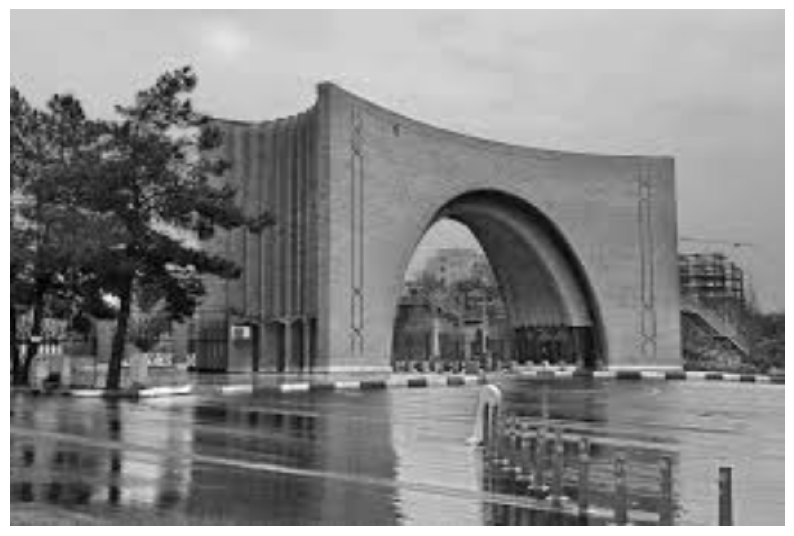

In [3]:
image_path = './img.jpeg'
image = Image.open(image_path)

image = image.convert('L')  # 'L' mode converts the image to grayscale

image = transforms.ToTensor()(image)

image = image.unsqueeze(dim=0)

image = transforms.Resize(size=(400, 600), antialias=True)(image)

print(f'Image type: {type(image)}')
print(f'Image shape: {image.shape}')

fig_o = plt.figure(figsize=(10, 7))
plt.imshow(image[0].permute(1, 2, 0), cmap='gray')  # Use 'gray' colormap for grayscale images
plt.axis('off')
plt.show()

Image type : <class 'torch.Tensor'>
Image shape : torch.Size([1, 3, 400, 600])


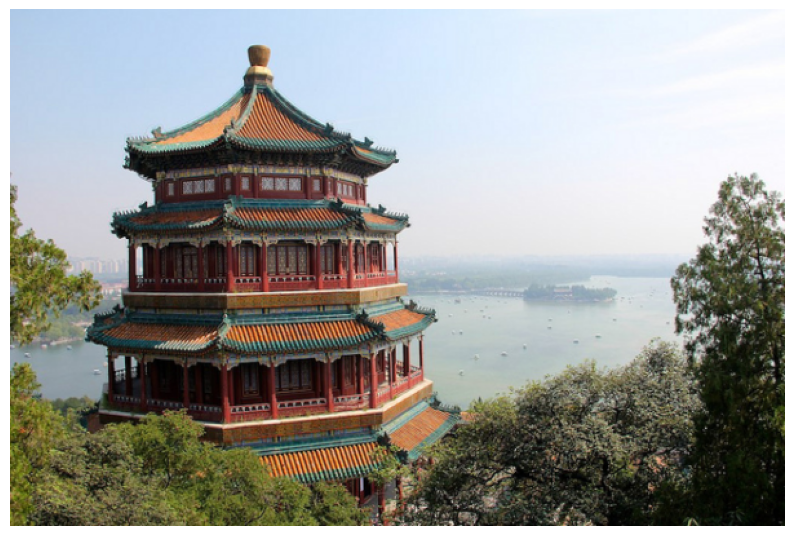

In [3]:
image = load_sample_image('china.jpg')
image = torch.tensor(image).permute(2, 0, 1) # converted to torch.Tensor type
image = image.unsqueeze(dim = 0) # as a batch size 
image = transforms.Resize(size=(400, 600), antialias=True)(image) # resize if needed 

print(f'Image type : {type(image)}')
print(f'Image shape : {image.shape}')

fig_o = plt.figure(figsize=(10, 7))
plt.imshow(image[0].permute(1, 2, 0))
# plt.title('$\mathcal{T}$', fontsize = 20)
plt.axis('off') 
plt.show()


# Attached Splitting - Map Type 1

Reshaped shape is : torch.Size([1, 1, 2, 2, 1, 200, 300])


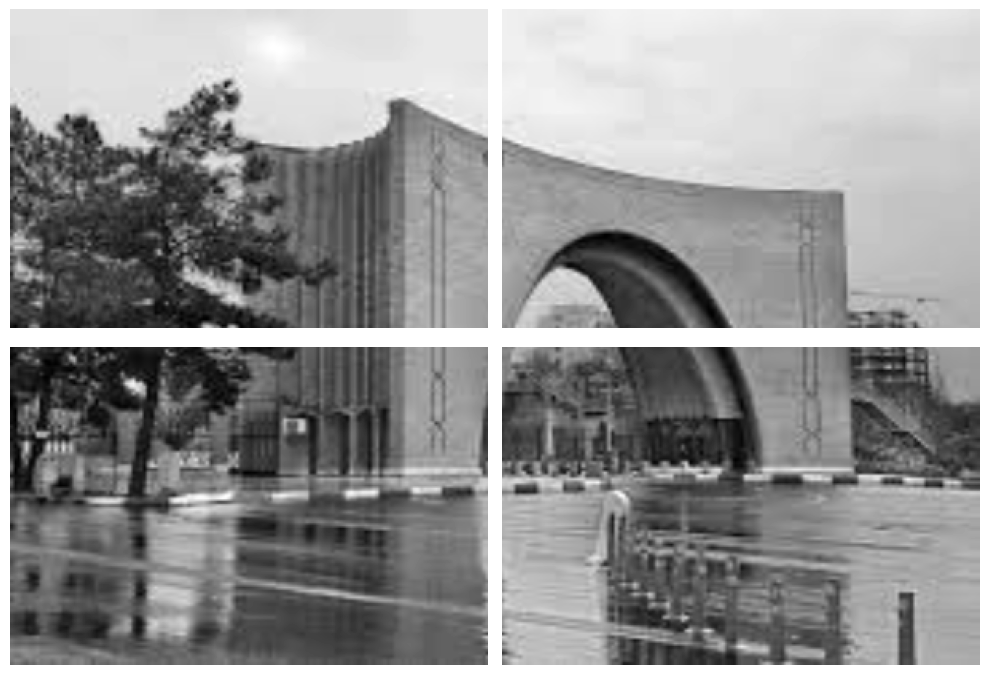

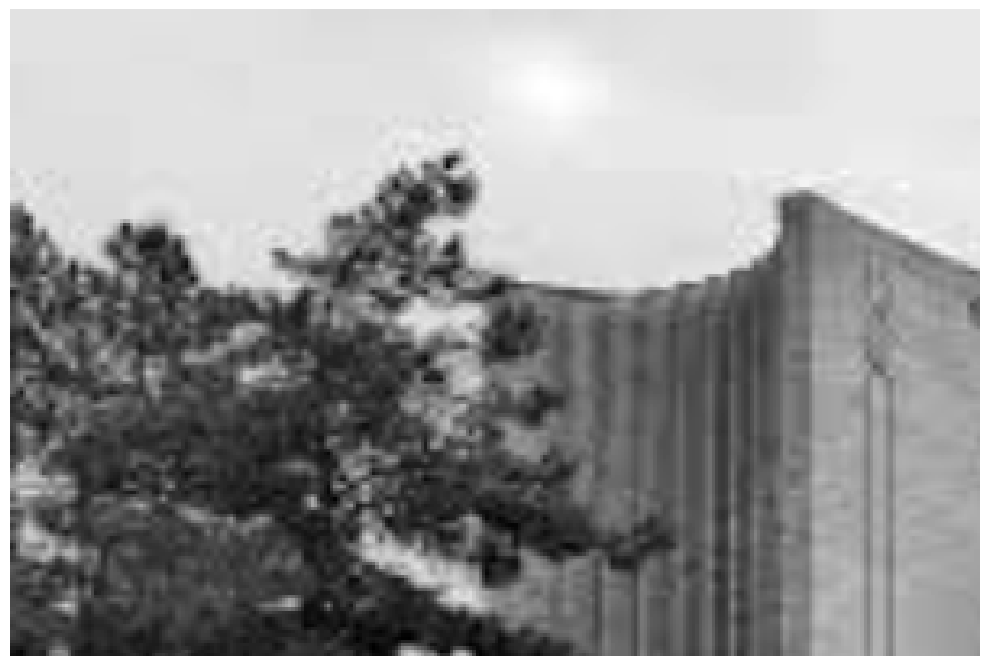

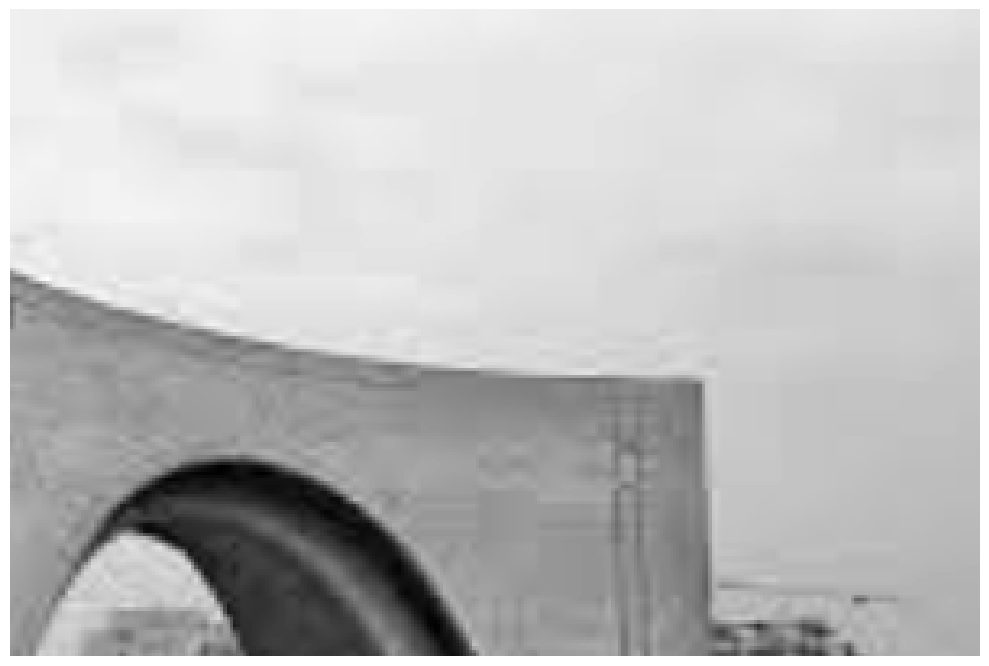

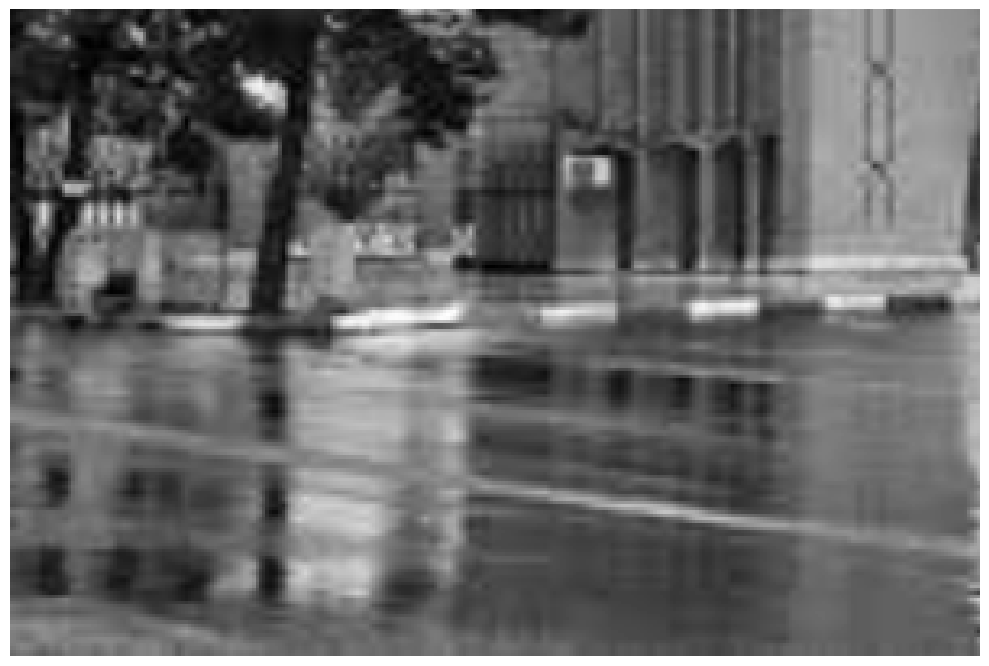

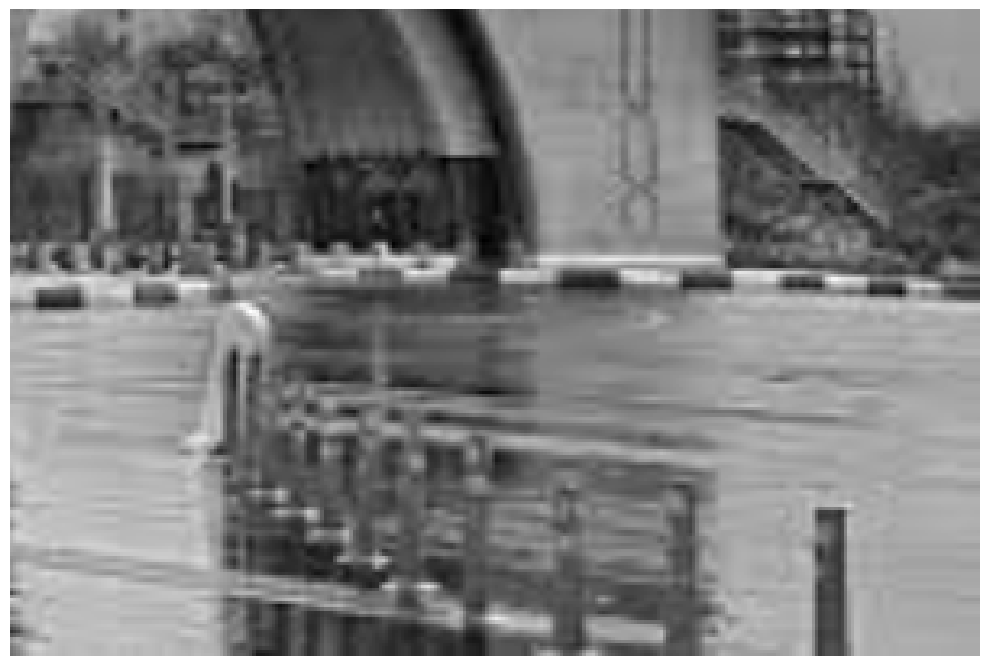

In [6]:
Reshape = reshape(split=[1, 2, 2], map_type=1, device = 'cpu') 

image_r1 = Reshape(image)
print(f'Reshaped shape is : {image_r1.shape}')

# Display the specified subset
fig_r1, axes = plt.subplots(2, 2, figsize=(10, 7))

for i in range(2):
    for j in range(2):
        subset = image_r1[0, 0, i, j, :, :, :]
        axes[i, j].imshow(subset.permute(1, 2, 0),  cmap='gray')  # Permute dimensions for plotting
        # axes[i, j].set_title('$\mathcal{T}$ ' + f'[ 0 , {i} , {j} , : , : , : ]', fontsize = 15)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()


# Display the specified subset

for i in range(2):
    for j in range(2):
        fig_r1 = plt.figure(figsize=(10, 7))
        subset = image_r1[0, 0, i, j, :, :, :]
        plt.imshow(subset.permute(1, 2, 0), cmap='gray')  # Permute dimensions for plotting
        # plt.title('$\mathcal{T}$ ' + f'[ 0 , {i} , {j} , : , : , : ]', fontsize = 20)
        plt.axis('off')
        plt.tight_layout()
        plt.show()



# Compressed Splitting - Map Type 2

Reshaped shape is : torch.Size([1, 1, 2, 2, 1, 200, 300])


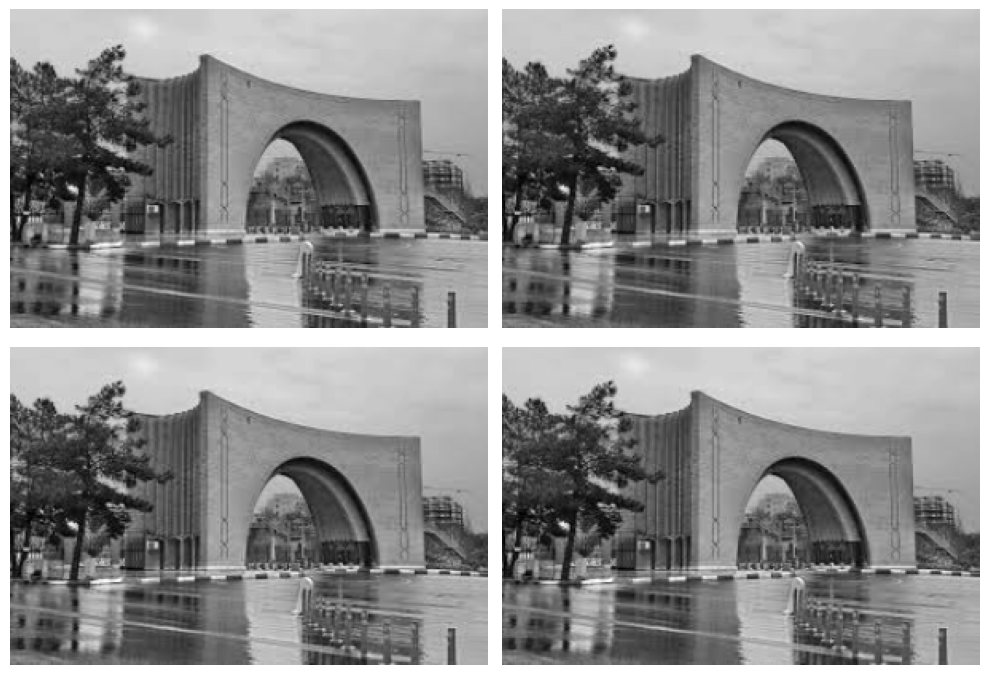

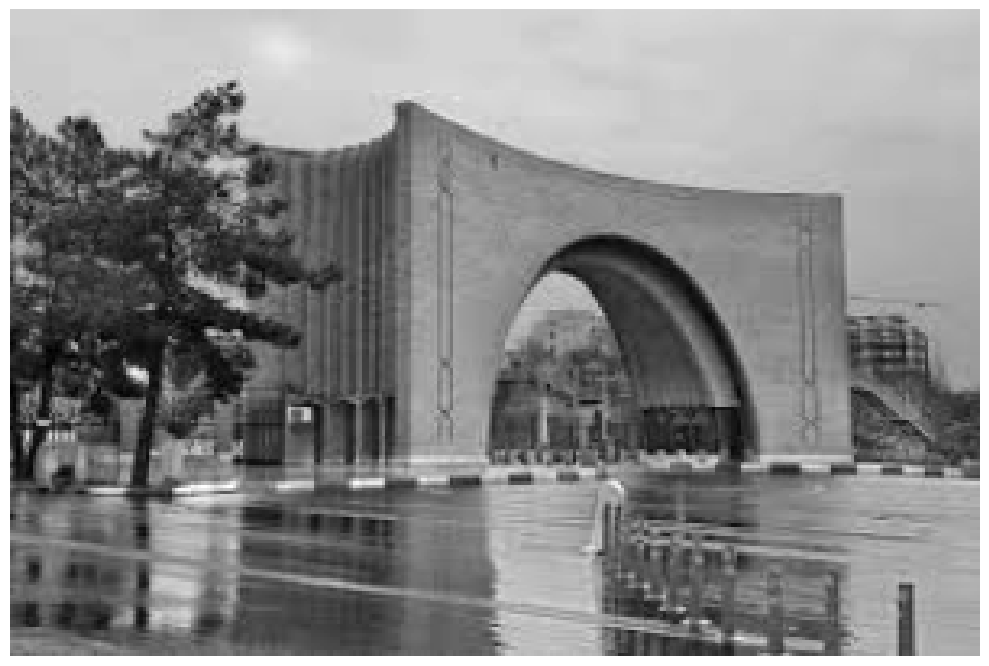

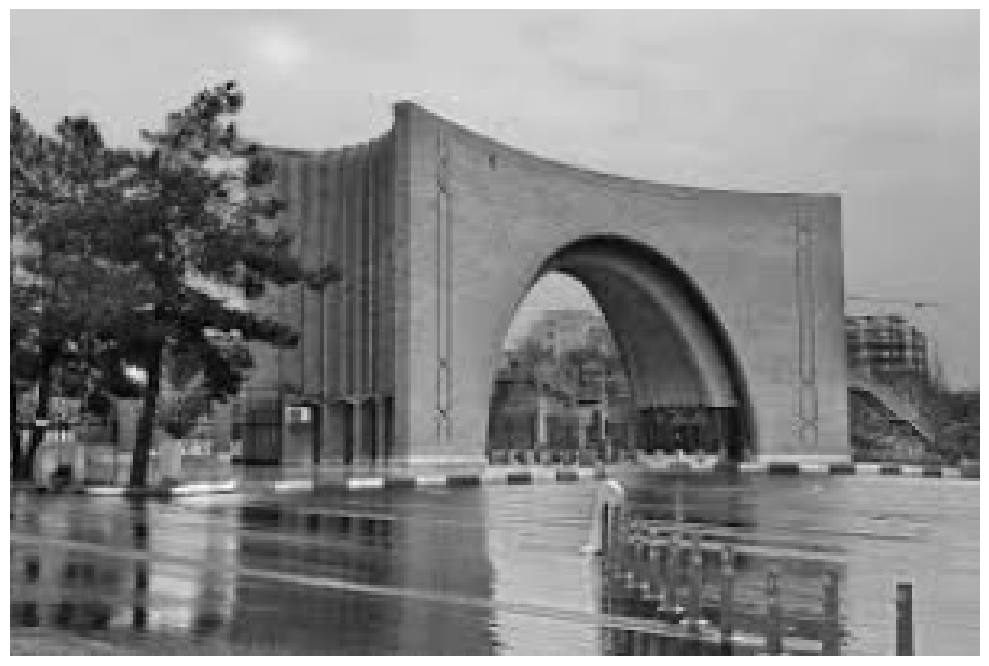

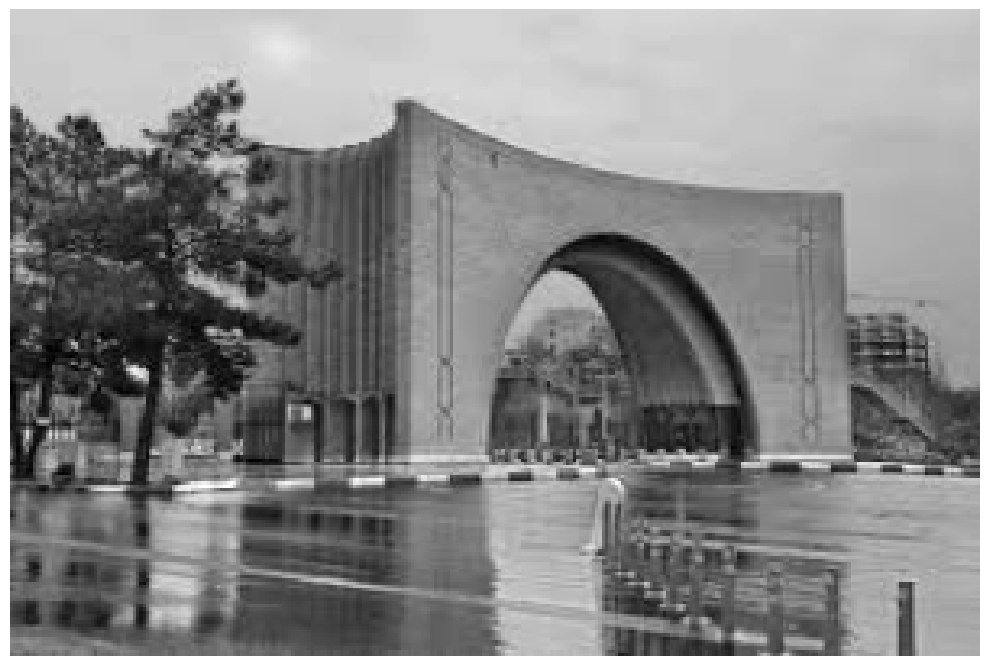

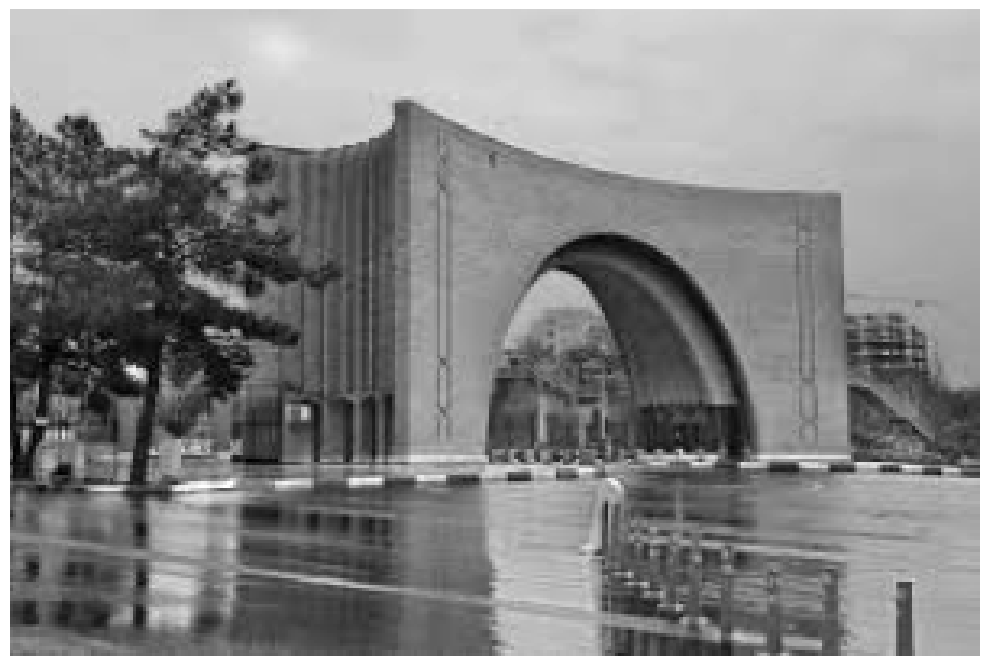

In [7]:
Reshape = reshape(split=[1, 2, 2], map_type=2, device = 'cpu') 

image_r2 = Reshape(image)
print(f'Reshaped shape is : {image_r2.shape}')

# Display the specified subset
fig_r2, axes = plt.subplots(2, 2, figsize=(10, 7))

for i in range(2):
    for j in range(2):
        subset = image_r2[0, 0, i, j, :, :, :]
        axes[i, j].imshow(subset.permute(1, 2, 0),  cmap='gray')  # Permute dimensions for plotting
        # axes[i, j].set_title('$\mathcal{T}$ ' + f'[ 0 , {i} , {j} , : , : , : ]')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Display the specified subset

for i in range(2):
    for j in range(2):
        fig_r2 = plt.figure(figsize=(10, 7))
        subset = image_r2[0, 0, i, j, :, :, :]
        plt.imshow(subset.permute(1, 2, 0),  cmap='gray')  # Permute dimensions for plotting
        # plt.title('$\mathcal{T}$ ' + f'[ 0 , {i} , {j} , : , : , : ]', fontsize = 20)
        plt.axis('off')
        plt.tight_layout()
        plt.show()


# Original Reshape - Pytorch

Reshaped shape is : torch.Size([1, 1, 2, 3, 3, 200, 200])


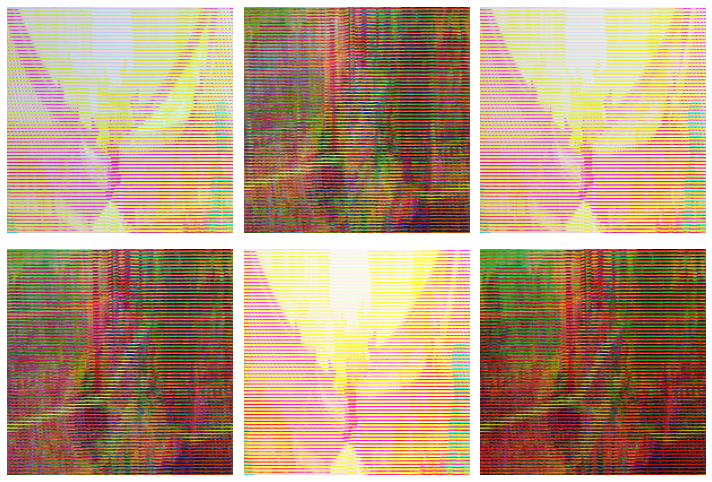

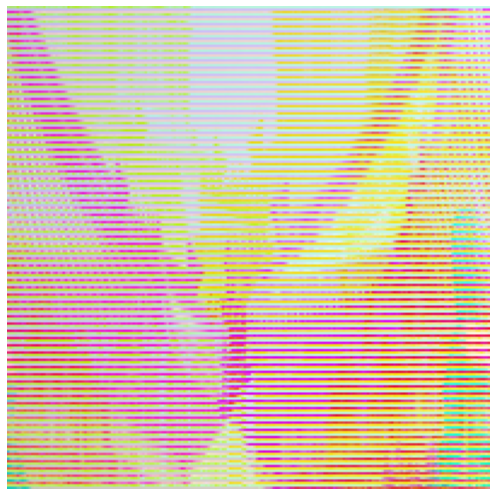

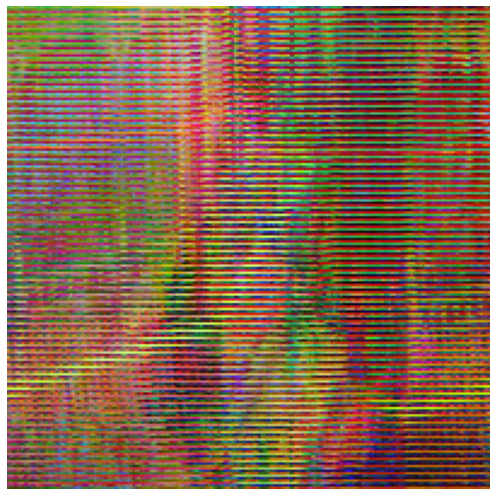

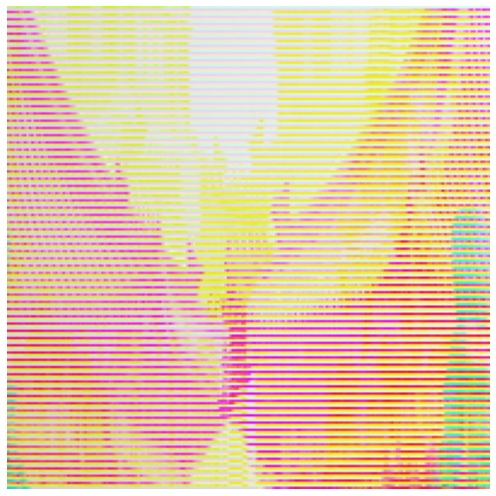

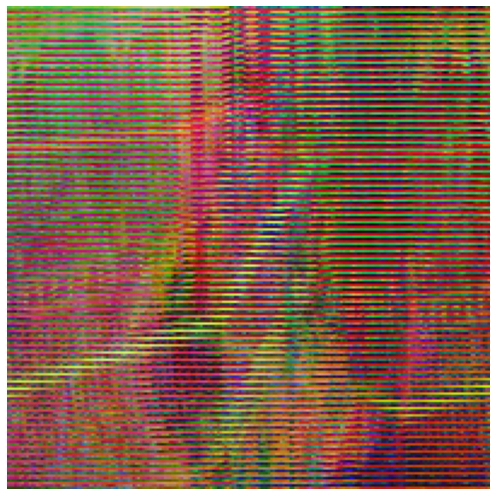

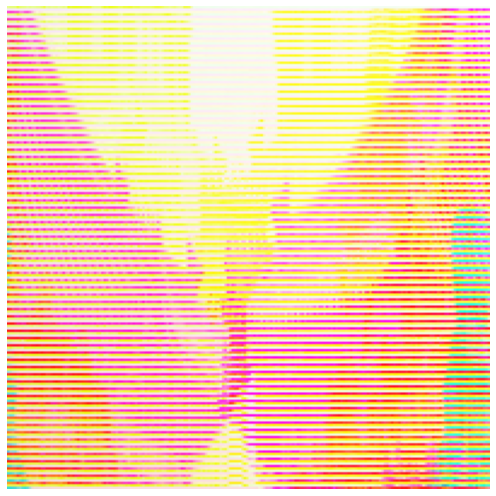

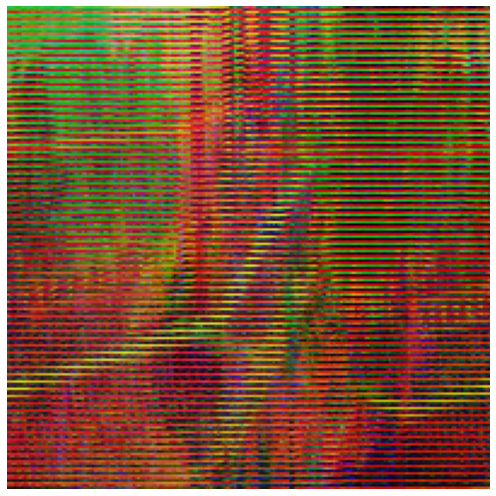

In [13]:
image_r3 = image.reshape((-1, 1, 2, 3, 3, 200,200))
print(f'Reshaped shape is : {image_r3.shape}')

# Display the specified subset
fig_r3, axes = plt.subplots(2, 3, figsize=(10, 7))

for i in range(2):
    for j in range(3):
        subset = image_r3[0, 0, i, j, :, :, :]
        axes[i, j].imshow(subset.permute(1, 2, 0))  # Permute dimensions for plotting
        # axes[i, j].set_title('$\mathcal{T}$ ' + f'[ 0 , {i} , {j} , : , : , : ]')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Display the specified subset

for i in range(2):
    for j in range(3):
        fig_r3 = plt.figure(figsize=(10, 7))
        subset = image_r3[0, 0, i, j, :, :, :]
        plt.imshow(subset.permute(1, 2, 0))  # Permute dimensions for plotting
        # plt.title('$\mathcal{T}$ ' + f'[ 0 , {i} , {j} , : , : , : ]', fontsize = 20)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
